In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from Camformer import Module, Camformer

In [17]:
df = pd.read_csv('modules.csv', dtype={'Node (nm)': int, 'Number': int})
modules = {}
for i in df.index:
    scale = df['Number'][i]
    module = Module(df['Power (mW)'][i] * scale , df['Area (um^2)'][i] * scale, 
                    df['Delay (cycles)'][i])
    modules[df['Module'][i]] = module

# Divide cam by 4 for 16X64 results
modules['BA-CAM 16X64'] = modules['BA-CAM 64X64']
modules['BA-CAM 16X64'].power /= 4
modules['BA-CAM 16X64'].area /= 4


#Assume programming = searching for now
# modules['cap_cam_64x64'].power2 = modules['cap_cam_64x64'].power 
# modules['cap_cam_64x64'].delay2 = modules['cap_cam_64x64'].delay
modules['BA-CAM 16X64'].power2 = modules['BA-CAM 16X64'].power
modules['BA-CAM 16X64'].delay2 = modules['BA-CAM 16X64'].delay

for k,v in modules.items():
    print(k, v)

Query Buffer Module(power=1.54, area=3750.0, delay=1, cycles=0, energy=0, power2=None, delay2=None)
Key SRAM Module(power=28.4, area=27728.6, delay=1, cycles=0, energy=0, power2=None, delay2=None)
BA-CAM 64X64 Module(power=25.2, area=3379.2, delay=1, cycles=0, energy=0, power2=25.2, delay2=1)
6b ADCs Module(power=15.2, area=64000.0, delay=2, cycles=0, energy=0, power2=None, delay2=None)
Fixed Scalers Module(power=0.752, area=2027.52, delay=2, cycles=0, energy=0, power2=None, delay2=None)
Top2 Module(power=11.660375, area=13335.36014, delay=2, cycles=0, energy=0, power2=None, delay2=None)
Ptop Reg Module(power=2.93, area=9155.0, delay=1, cycles=0, energy=0, power2=None, delay2=None)
Top32 Module(power=99.81453333, area=101540.8019, delay=6, cycles=0, energy=0, power2=None, delay2=None)
SoftMax LUT Module(power=1.418, area=1612.373532, delay=1, cycles=0, energy=0, power2=None, delay2=None)
SoftMax Div. Module(power=0.07109, area=441.529, delay=3, cycles=0, energy=0, power2=None, delay2=N

None
0.123046875


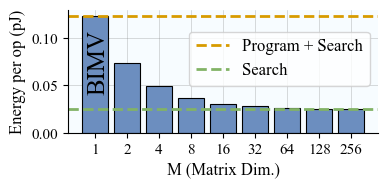

In [111]:
power = modules['BA-CAM 16X64'].power
area = modules['BA-CAM 16X64'].area

# assume writing 4 rows = same as searching fully array
# GEMM where A is mxk and b is kxn
# assume that k = 64
# BACAM operatoin
# Load 16 rows of B
# Search m row of A
# Write k col of C
search_to_mac = 16 * 64

k = 64
# n = np.arange(4, 16, 2)
# n = np.power(2, n)
m = np.arange(0, 9, 1)
m = np.power(2, m)

i  = 16
ops = m * i * 64 # total ops (macs)
writes = i // 4
searches = m * (i // 16)
energy = power * (searches + writes)

colors = {
    'CAMformer': '#6C8EBF',
    'Spatten': '#B85450',
    'Cerebras WSE2': '#D79B00',
    'Groq TSP': '#9673A6',
    'TPUv4': '#82B366'
}

# Change plot font to helvetiva
plt.rcParams.update({'font.family': 'Times New Roman'})

plt.figure(figsize=(4, 2*4/5))
plt.grid(linewidth=0.4, color='gray', linestyle='-', alpha=0.5)
plt.gca().set_axisbelow(True)
print(plt.gca().get_ygridlines()[3].set_visible(False))

plt.gca().set_facecolor('#f7fcff')

plt.bar(np.arange(0,9,1), energy/ops, edgecolor='black', color=colors['CAMformer'], width=0.8, linewidth=0.8)
plt.annotate('BIMV', xy=(0.1, 0.075), rotation=90, fontsize=18, color='black', ha='center', va='center')
plt.axhline(y=max(energy/ops), color=colors['Cerebras WSE2'], linestyle='--', label="Program + Search", linewidth=2)
plt.axhline(y=power/search_to_mac, color=colors['TPUv4'], linestyle='--', label="Search", linewidth=2)
plt.xlabel('M (Matrix Dim.)', fontsize=12)
plt.ylabel('Energy per op (pJ)', fontsize=12)
plt.xticks(ticks=np.arange(0,9,1),labels=m, fontsize=11)
plt.yticks(fontsize=11)
plt.ylim(0, 0.13)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.legend(loc='center right', fontsize=12, bbox_to_anchor=(1, 0.6), frameon=True)
plt.savefig('bimm_energy.png', bbox_inches='tight', dpi=300)
print(max(energy/ops))